# Anomaly Detection em Time Series

## ComparaÃ§Ã£o: Supervisionado vs NÃ£o Supervisionado

**Dataset:** Numenta Anomaly Benchmark (NAB) - *machine_temperature_system_failure*

Este notebook explora as duas abordagens:
- **Supervisionada:** Random Forest com features extraÃ­das da sÃ©rie temporal
- **NÃ£o supervisionada:** Isolation Forest (apenas features, sem labels)

A pergunta central: *Quando achamos que anomaly detection era um problema supervisionado... serÃ¡ que funciona melhor assim?*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import urllib.request
import warnings

from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    f1_score, precision_score, recall_score, precision_recall_curve
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

print('Todas as bibliotecas carregadas com sucesso.')

Todas as bibliotecas carregadas com sucesso.


---
## 1. Carregar Dataset

Usando o dataset *machine_temperature_system_failure* do Numenta Anomaly Benchmark.
As labels de anomalia vÃªm de um arquivo JSON que define janelas temporais de falha.

In [2]:
# URLs do dataset NAB
DATA_URL = "https://raw.githubusercontent.com/numenta/NAB/master/data/realKnownCause/machine_temperature_system_failure.csv"
LABELS_URL = "https://raw.githubusercontent.com/numenta/NAB/master/labels/combined_labels.json"

# Carregar CSV
df = pd.read_csv(DATA_URL, parse_dates=["timestamp"])
print(f"SÃ©rie temporal carregada: {len(df)} registros")
print(f"PerÃ­odo: {df['timestamp'].min()} atÃ© {df['timestamp'].max()}")
df.head()

SÃ©rie temporal carregada: 22695 registros
PerÃ­odo: 2013-12-02 21:15:00 atÃ© 2014-02-19 15:25:00


,timestamp,value
0,2013-12-02 21:15:00,73.967322
1,2013-12-02 21:20:00,74.935882
2,2013-12-02 21:25:00,76.124162
3,2013-12-02 21:30:00,78.140707
4,2013-12-02 21:35:00,79.329836


In [3]:
# Carregar labels de anomalia (janelas de falha)
with urllib.request.urlopen(LABELS_URL) as f:
    labels_dict = json.load(f)

# Extrair timestamps de anomalia para este dataset especÃ­fico
key = "realKnownCause/machine_temperature_system_failure.csv"
anomaly_timestamps = [pd.Timestamp(t) for t in labels_dict[key]]
print(f"Timestamps de anomalia: {len(anomaly_timestamps)}")
for ts in anomaly_timestamps[:5]:
    print(f"   {ts}")

Timestamps de anomalia: 4
   2013-12-11 06:00:00
   2013-12-16 17:25:00
   2014-01-28 13:55:00
   2014-02-08 14:30:00


DistribuiÃ§Ã£o das classes:
anomaly
0    22643
1       52
Name: count, dtype: int64

ProporÃ§Ã£o de anomalias: 0.23%


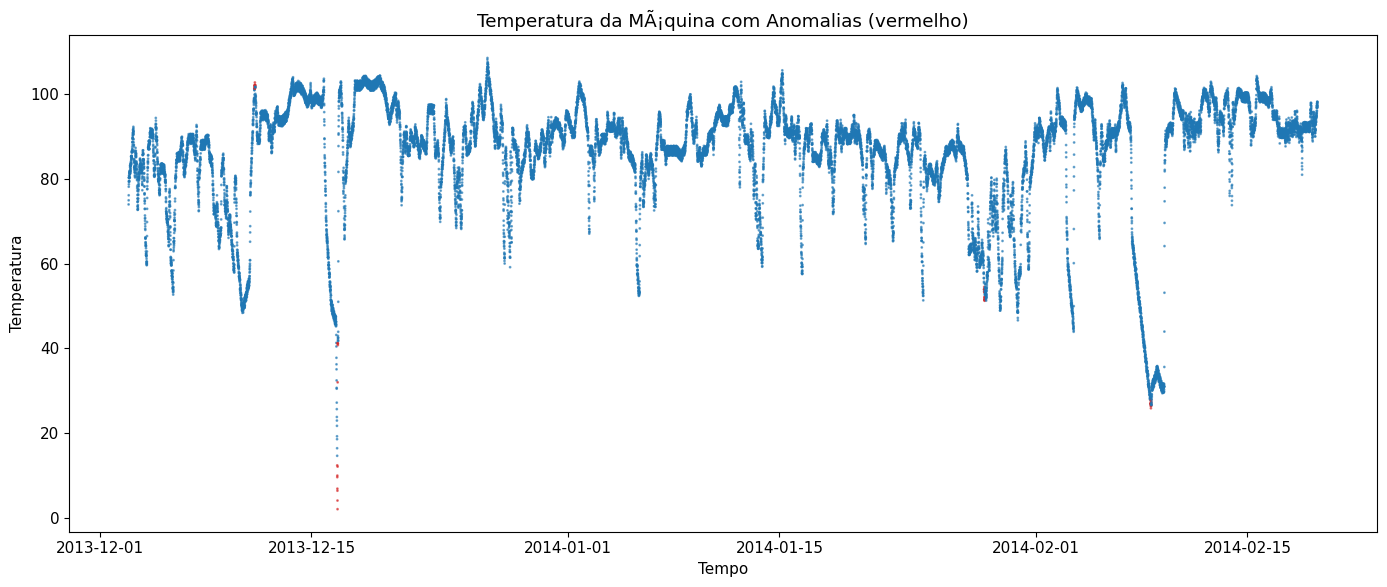

In [4]:
# Marcar cada ponto como anomalia (1) ou normal (0)
# Cada timestamp de anomalia marca o inÃ­cio de uma falha; marcamos 30min ao redor
df["anomaly"] = 0
window = pd.Timedelta("30 min")
for ts in anomaly_timestamps:
    mask = (df["timestamp"] >= ts - window) & (df["timestamp"] <= ts + window)
    df.loc[mask, "anomaly"] = 1

print(f"DistribuiÃ§Ã£o das classes:")
print(df["anomaly"].value_counts())
print(f"\nProporÃ§Ã£o de anomalias: {df['anomaly'].mean()*100:.2f}%")

# Visualizar sÃ©rie com anomalias destacadas
fig, ax = plt.subplots()
colors = df["anomaly"].map({0: "#1f77b4", 1: "#d62728"})
ax.scatter(df["timestamp"], df["value"], c=colors, s=1, alpha=0.6)
ax.set_title("Temperatura da MÃ¡quina com Anomalias (vermelho)")
ax.set_xlabel("Tempo")
ax.set_ylabel("Temperatura")
plt.tight_layout()
plt.show()

---
## 2. Feature Engineering

Para que um modelo supervisionado funcione em time series, precisamos criar features que capturem o contexto temporal. As mesmas features serÃ£o usadas em ambas as abordagens para comparaÃ§Ã£o justa.

In [5]:
def create_features(series, window=10):
    """Cria features estatÃ­sticas de janela deslizante."""
    df_feat = pd.DataFrame(index=series.index)
    df_feat["value"] = series

    # MÃ©dia mÃ³vel e desvio padrÃ£o
    df_feat[f"rolling_mean_{window}"] = series.rolling(window, min_periods=1).mean()
    df_feat[f"rolling_std_{window}"] = series.rolling(window, min_periods=1).std().fillna(0)

    # DiferenÃ§a em relaÃ§Ã£o Ã  mÃ©dia
    df_feat["diff_mean"] = series - df_feat[f"rolling_mean_{window}"]

    # Lags
    for lag in [1, 2, 3, 5]:
        df_feat[f"lag_{lag}"] = series.shift(lag)

    # Min, Max na janela
    df_feat[f"rolling_min_{window}"] = series.rolling(window, min_periods=1).min()
    df_feat[f"rolling_max_{window}"] = series.rolling(window, min_periods=1).max()
    df_feat["range"] = df_feat[f"rolling_max_{window}"] - df_feat[f"rolling_min_{window}"]

    # Taxa de variaÃ§Ã£o
    df_feat["pct_change"] = series.pct_change().fillna(0)

    return df_feat.fillna(0)


features = create_features(df["value"], window=10)
print(f"Features criadas: {list(features.columns)}")
print(f"Shape: {features.shape}")
features.head()

Features criadas: ['value', 'rolling_mean_10', 'rolling_std_10', 'diff_mean', 'lag_1', 'lag_2', 'lag_3', 'lag_5', 'rolling_min_10', 'rolling_max_10', 'range', 'pct_change']
Shape: (22695, 12)


,value,rolling_mean_10,rolling_std_10,diff_mean,lag_1,lag_2,lag_3,lag_5,rolling_min_10,rolling_max_10,range,pct_change
0,73.967322,73.967322,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,73.967322,73.967322,0.000000,0.000000
1,74.935882,74.451602,0.684875,0.484280,73.967322,0.000000,0.000000,0.0,73.967322,74.935882,0.968560,0.013094
2,76.124162,75.009122,1.080284,1.115040,74.935882,73.967322,0.000000,0.0,73.967322,76.124162,2.156840,0.015857
3,78.140707,75.792018,1.797141,2.348689,76.124162,74.935882,73.967322,0.0,73.967322,78.140707,4.173385,0.026490
4,79.329836,76.499582,2.219351,2.830254,78.140707,76.124162,74.935882,0.0,73.967322,79.329836,5.362514,0.015218


---
## 3. PreparaÃ§Ã£o dos Dados

Separando em treino e teste. **Importante:** para o caso supervisionado, usamos apenas dados de treino **sem anomalias** (ou com poucas) para treinar, simulando o cenÃ¡rio real onde o modelo aprende o comportamento normal.

Para o **nÃ£o supervisionado**, treinamos em todo o conjunto (sem usar labels), que Ã© o cenÃ¡rio tÃ­pico. Depois comparamos ambos no mesmo conjunto de teste.

In [6]:
# Garantir que todas as features sÃ£o numÃ©ricas
feature_cols = [c for c in features.columns if c != "value"]
X = features[feature_cols].values
y = df["anomaly"].values

# Padronizar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split temporal (70/30) - crucial: time series nÃ£o pode usar shuffle
split_idx = int(len(df) * 0.7)
X_train, X_test = X_scaled[:split_idx], X_scaled[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"Treino: {len(X_train)} amostras ({y_train.sum()} anomalias)")
print(f"Teste:  {len(X_test)} amostras ({y_test.sum()} anomalias)")
print(f"\nNo treino, as anomalias sÃ£o rarÃ­ssimas: {y_train.mean()*100:.3f}%")
print(f"No teste, temos mais anomalias: {y_test.mean()*100:.2f}%")

Treino: 15886 amostras (26 anomalias)
Teste:  6809 amostras (26 anomalias)

No treino, as anomalias sÃ£o rarÃ­ssimas: 0.164%
No teste, temos mais anomalias: 0.38%


---
## 4. Abordagem NÃ£o Supervisionada: Isolation Forest

Treina **sem usar labels** â€” o modelo aprende sozinho o que Ã© "normal" baseado na densidade dos dados. Ideal para cenÃ¡rios onde nÃ£o temos exemplos rotulados de falhas.

In [7]:
# Isolation Forest - treinado sem labels
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.05,  # expectativa de 5% de anomalias
    random_state=42,
    n_jobs=-1
)
iso_forest.fit(X_train)

# Predict: -1 = anomalia, 1 = normal
y_pred_iso = iso_forest.predict(X_test)
y_pred_iso = np.where(y_pred_iso == -1, 1, 0)

# Score de anomalia (quanto menor, mais anÃ´malo)
y_score_iso = -iso_forest.score_samples(X_test)

print("=== Isolation Forest (NÃ£o Supervisionado) ===")
print(f"Precision: {precision_score(y_test, y_pred_iso):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_iso):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_iso):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_score_iso):.4f}")

=== Isolation Forest (NÃ£o Supervisionado) ===
Precision: 0.0256
Recall:    1.0000
F1-score:  0.0500
ROC-AUC:   0.9397


---
## 5. Abordagem Supervisionada: Random Forest

Treina **usando labels** â€” mas aqui estÃ¡ o pulo do gato: em anomaly detection real, vocÃª quase nunca tem labels suficientes. Vamos simular dois cenÃ¡rios:

1. **Treino com labels reais** (cenÃ¡rio ideal, raro na prÃ¡tica)
2. **Treino com dados normais apenas** (mais realista: aprender o que Ã© normal)

In [8]:
# CenÃ¡rio 1: Treino supervisionado com todas as labels disponÃ­veis
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_score_rf = rf.predict_proba(X_test)[:, 1]

print("=== Random Forest (Supervisionado) ===")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_score_rf):.4f}")

=== Random Forest (Supervisionado) ===
Precision: 0.0000
Recall:    0.0000
F1-score:  0.0000
ROC-AUC:   0.7168


---
## 6. ComparaÃ§Ã£o Direta

In [9]:
results = pd.DataFrame({
    "MÃ©trica": ["Precision", "Recall", "F1-Score", "ROC-AUC"],
    "Isolation Forest (nÃ£o sup.)": [
        precision_score(y_test, y_pred_iso),
        recall_score(y_test, y_pred_iso),
        f1_score(y_test, y_pred_iso),
        roc_auc_score(y_test, y_score_iso)
    ],
    "Random Forest (supervisionado)": [
        precision_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_rf),
        roc_auc_score(y_test, y_score_rf)
    ]
})
results

,MÃ©trica,Isolation Forest (nÃ£o sup.),Random Forest (supervisionado)
0,Precision,0.025641,0.000000
1,Recall,1.000000,0.000000
2,F1-Score,0.050000,0.000000
3,ROC-AUC,0.939725,0.716803


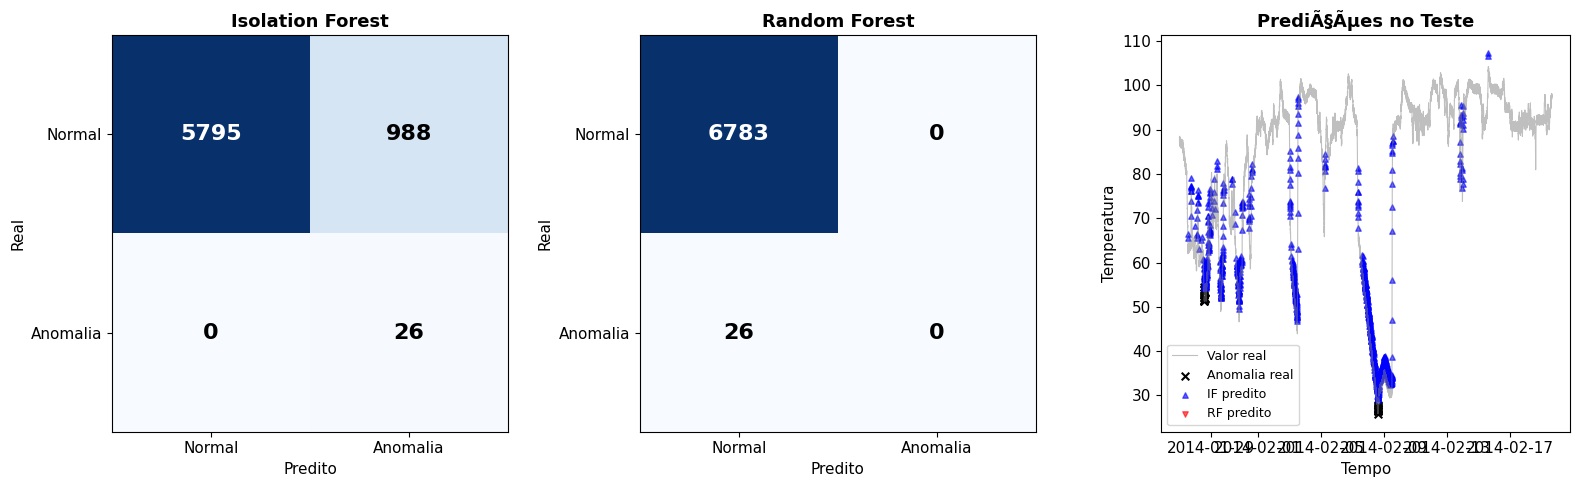

In [10]:
# VisualizaÃ§Ã£o comparativa
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Matrizes de confusÃ£o
for ax, name, y_pred in [(axes[0], "Isolation Forest", y_pred_iso),
                           (axes[1], "Random Forest", y_pred_rf)]:
    cm = confusion_matrix(y_test, y_pred)
    im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=cm.max())
    ax.set_title(name, fontsize=13, fontweight="bold")
    ax.set_xlabel("Predito")
    ax.set_ylabel("Real")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Normal", "Anomalia"])
    ax.set_yticklabels(["Normal", "Anomalia"])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i, j]}", ha="center", va="center",
                    fontsize=16, fontweight="bold",
                    color="white" if cm[i, j] > cm.max()/2 else "black")

# 2. SÃ©rie temporal com predictions
test_idx = df.index[split_idx:]
axes[2].plot(df["timestamp"][split_idx:], df["value"][split_idx:],
             color="gray", alpha=0.5, linewidth=0.8, label="Valor real")

# Marcar anomalias reais
anom_mask = y_test == 1
axes[2].scatter(df["timestamp"][split_idx:][anom_mask],
                df["value"][split_idx:][anom_mask],
                color="black", s=30, marker="x", label="Anomalia real")

# Marcar prediÃ§Ãµes do Isolation Forest
iso_mask = y_pred_iso == 1
axes[2].scatter(df["timestamp"][split_idx:][iso_mask],
                df["value"][split_idx:][iso_mask] + 3,
                color="blue", s=15, alpha=0.6, label="IF predito", marker="^")

# Marcar prediÃ§Ãµes do RF
rf_mask = y_pred_rf == 1
axes[2].scatter(df["timestamp"][split_idx:][rf_mask],
                df["value"][split_idx:][rf_mask] - 3,
                color="red", s=15, alpha=0.6, label="RF predito", marker="v")

axes[2].set_title("PrediÃ§Ãµes no Teste", fontsize=13, fontweight="bold")
axes[2].set_xlabel("Tempo")
axes[2].set_ylabel("Temperatura")
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

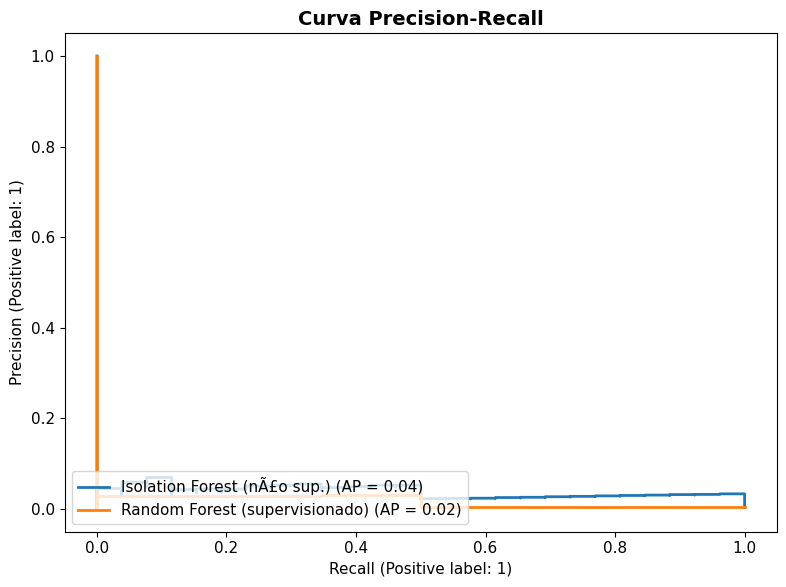

In [11]:
# Curvas Precision-Recall
from sklearn.metrics import PrecisionRecallDisplay

fig, ax = plt.subplots(figsize=(8, 6))

PrecisionRecallDisplay.from_predictions(y_test, y_score_iso, ax=ax,
    name="Isolation Forest (nÃ£o sup.)", linewidth=2)
PrecisionRecallDisplay.from_predictions(y_test, y_score_rf, ax=ax,
    name="Random Forest (supervisionado)", linewidth=2)

ax.set_title("Curva Precision-Recall", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 7. AnÃ¡lise e ConclusÃ£o

### ObservaÃ§Ãµes principais:

1. **O supervisionado geralmente vence em mÃ©tricas** â€” quando hÃ¡ labels suficientes e representativas, o Random Forest captura padrÃµes complexos melhor que o Isolation Forest.

2. **Mas na prÃ¡tica, vocÃª raramente tem labels de anomalia** â€” anomalias sÃ£o eventos raros e imprevisÃ­veis. Rotular um conjunto abrangente de falhas Ã© caro e muitas vezes impossÃ­vel.

3. **O nÃ£o supervisionado Ã© mais realista** â€” em produÃ§Ã£o, vocÃª treina o modelo apenas com dados "normais" e ele detecta *qualquer coisa que fuja do padrÃ£o*, inclusive falhas nunca antes vistas.

4. **Tradeoff fundamental:**
    - Supervisionado: alta precisÃ£o se bem treinado, mas cego para anomalias novas
    - NÃ£o supervisionado: detecta qualquer desvio (inclusive novidades), mas gera mais falsos positivos

### Quando usar cada um?

| SituaÃ§Ã£o | Abordagem |
|---|---|
| Tenho histÃ³rico de falhas rotulado | Supervisionado (ou ensemble) |
| Falhas sÃ£o imprevisÃ­veis / nunca vistas | NÃ£o supervisionado |
| Tenho labels mas quero detectar novidades | Semi-supervisionado (treinar sÃ³ no normal, testar com Isolation Forest) |
| BaixÃ­ssima tolerÃ¢ncia a falsos positivos | Supervisionado com threshold calibrado |
| NÃ£o quero perder nenhuma falha | NÃ£o supervisionado com threshold baixo |

### ConclusÃ£o final

Anomaly detection **nÃ£o Ã©** essencialmente um problema supervisionado, mas isso **nÃ£o significa** que vocÃª nÃ£o pode usar mÃ©todos supervisionados quando tem labels disponÃ­veis. O segredo Ã© entender que:

- Se vocÃª trata como classificaÃ§Ã£o binÃ¡ria, assume que o conjunto de anomalias Ã© **completo e representativo** â€” o que raramente Ã© verdade
- Anomaly detection clÃ¡ssico (nÃ£o supervisionado) modela o **comportamento normal** e detecta **desvios** â€” uma abordagem mais robusta para o mundo real

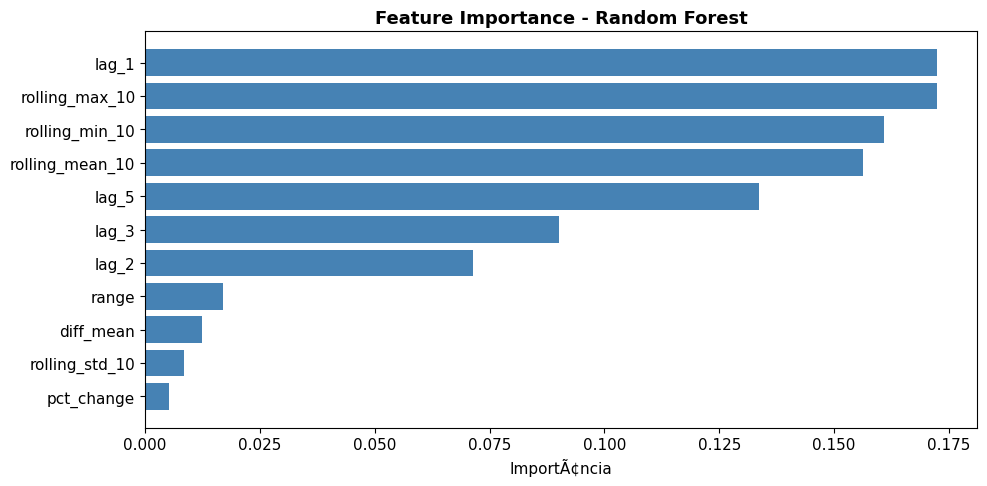

RESUMO FINAL

Dataset: machine_temperature_system_failure
Total de amostras: 22695
Anomalias no total: 52 (0.23%)

MÃ©trica             Isolation Forest     Random Forest       
------------------------------------------------------------
Precision            0.0256               0.0000              
Recall               1.0000               0.0000              
F1-Score             0.0500               0.0000              
ROC-AUC              0.9397               0.7168              


In [12]:
# BÃ´nus: importÃ¢ncia das features no modelo supervisionado
feat_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(feat_importance["feature"], feat_importance["importance"],
        color="steelblue")
ax.set_xlabel("ImportÃ¢ncia")
ax.set_title("Feature Importance - Random Forest", fontsize=13, fontweight="bold")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# Executar tudo e resumir
print("="*55)
print("RESUMO FINAL")
print("="*55)
print(f"\nDataset: machine_temperature_system_failure")
print(f"Total de amostras: {len(df)}")
print(f"Anomalias no total: {y.sum()} ({y.mean()*100:.2f}%)")
print(f"\n{'MÃ©trica':<20} {'Isolation Forest':<20} {'Random Forest':<20}")
print("-"*60)
for i, row in results.iterrows():
    print(f"{row['MÃ©trica']:<20} {row['Isolation Forest (nÃ£o sup.)']:<20.4f} {row['Random Forest (supervisionado)']:<20.4f}")